In [4]:
import torch
from torch.utils.data import TensorDataset, DataLoader
from NO import *
import pickle
from special_loss_functions import *
import matplotlib.pyplot as plt

In [5]:
def train(model, dataloader, loss_fun, optimizer, device):
    model.train()
    train_error = 0
    nbatches = len(dataloader)
    for (X, y) in dataloader:
        X, y = X.to(device), y.to(device)
        pred = model(X)
        loss = loss_fun(pred, y)
        loss.backward()
        optimizer.step()
        train_error += loss.item()
        optimizer.zero_grad()
    train_error /= nbatches 
    return train_error

def test(model, dataloader, loss_fun, device):
    model.eval()
    test_error = 0
    nbatches = len(dataloader)
    with torch.no_grad():
        for (X, y) in dataloader:
            X, y =  X.to(device), y.to(device)
            pred = model(X)
            loss = loss_fun(pred, y)
            test_error += loss.item()
    test_error /= nbatches
    return test_error

In [6]:
def make_training_testing_datasets(data, history, batch_size, training_size=1024):

    # select
    features = torch.tensor(data[:-history, :])
    labels = [torch.tensor(data[i+1:i+history+1, :]).t() for i in range(len(data)-history)]

    # re-arrange
    features = torch.reshape(features, features.shape + (1,)).to(torch.float32)
    labels = torch.stack(labels)
    labels = torch.reshape(labels, labels.shape + (1,)).to(torch.float32)

    # create datasets
    idx = torch.randperm(training_size)
    training_dataset = TensorDataset(features[idx, :, :], labels[idx, :, :, :])
    testing_dataset = TensorDataset(features[training_size:, :, :], labels[training_size:, :, :, :])

    # create dataloaders
    training_dataloader = DataLoader(training_dataset, batch_size=batch_size, shuffle=True)
    testing_dataloader = DataLoader(testing_dataset, batch_size=batch_size, shuffle=True)

    dimensions = labels.shape
    
    return training_dataloader, testing_dataloader, dimensions

In [7]:
# load data
device = "cpu"
with open('data/KuramotoSivashinsky/KS_N32.pkl', 'rb') as file:
    data = pickle.load(file)

In [27]:
# create data structures
history = 5
batch_size = 64
training_dataloader, testing_dataloader, dimensions = make_training_testing_datasets(data, history, batch_size)

In [28]:
# create model
Nf = dimensions[-1]
Nx = dimensions[1]
Nlifted = 16 # 32 works
Nk_truncated = 10
depth = history

model = PFNO(
            (Nx, Nf), 
            Nlifted, 
            (Nk_truncated,), 
            depth
            ).to(device) 

lr = 2e-04
optimizer = torch.optim.Adam(model.parameters(), lr = lr)
loss_fun = H1Loss(reduction='mean', dim=1)

In [7]:
# inference
epochs = 500
for epoch in range(epochs):
    train_loss = train(model, training_dataloader, loss_fun, optimizer, device)
    if epoch % 100 == 0: 
        print(f' Training error: {train_loss}, Testing error: {test(model, testing_dataloader, loss_fun, device)}')
        lr *= 0.8
        optimizer = torch.optim.Adam(model.parameters(), lr = lr)

 Training error: 2.0851170122623444, Testing error: 2.1053348034620285
 Training error: 0.45383618026971817, Testing error: 0.4576036427170038
 Training error: 0.40569987893104553, Testing error: 0.40876233391463757
 Training error: 0.04053903906606138, Testing error: 0.03786192648112774
 Training error: 0.009293091716244817, Testing error: 0.0060230336675886065


# Debugging
## train on small batch

 Training error: 1.9234264492988586, Testing error: 2.322057970234605
 Training error: 0.033705536276102066, Testing error: 0.5500525812633702
 Training error: 0.0013044175575487316, Testing error: 0.22657387960152547
 Training error: 0.0003878406423609704, Testing error: 0.18815904635874953
 Training error: 0.00025879728491418064, Testing error: 0.17643571119816576
 Training error: 0.00020429116557352245, Testing error: 0.17024283575229956
 Training error: 0.00017038204532582313, Testing error: 0.1647798660837236
 Training error: 0.00015118940791580826, Testing error: 0.16173423191563027
 Training error: 0.00013920047058491036, Testing error: 0.15982977777230936
 Training error: 0.000130648219055729, Testing error: 0.15760247213918654


[]

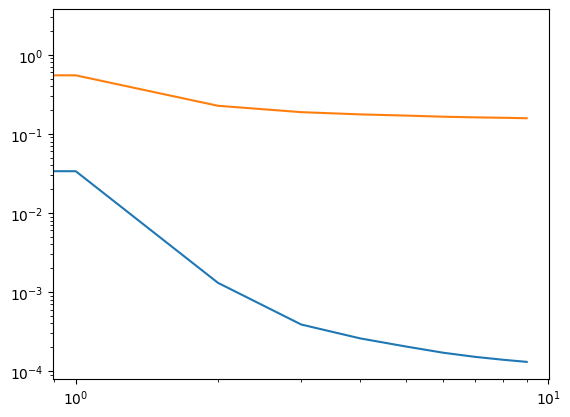

In [47]:
def train_small(model, dataloader, loss_fun, optimizer, device):
    #model.train()
    model.eval() # cancels dropout, enables overfitting
    train_error = 0
    nbatches = len(dataloader)
    for (X, y) in dataloader:
        X, y = X.to(device), y.to(device)
        pred = model(X)
        loss = loss_fun(pred, y)
        loss.backward()
        optimizer.step()
        train_error += loss.item()
        optimizer.zero_grad()
    train_error /= nbatches 
    return train_error
    
# test on small dataset
history = 5
batch_size = 32
training_dataloader_small, testing_dataloader_small, dimensions = make_training_testing_datasets(data, history, batch_size, 2*batch_size)

# create model
Nf = dimensions[-1]
Nx = dimensions[1]
Nlifted = 16 # 32 works
Nk_truncated = 10
depth = history
lr = 5E-04

model = PFNO(
            (Nx, Nf), 
            Nlifted, 
            (Nk_truncated,), 
            depth
            ).to(device) 

loss_fun = H1Loss(reduction='mean', dim=1)

train_errors = []
validation_errors = []
optimizer = torch.optim.Adam(model.parameters(), lr = 2e-04)

epochs = 2000
for epoch in range(epochs):
    
    train_loss = train_small(model, training_dataloader_small, loss_fun, optimizer, device)
    test_loss = test(model, testing_dataloader_small, loss_fun, device)

    if epoch % 200 == 0: 
        train_errors += [train_loss]
        validation_errors += [test_loss]
        print(f' Training error: {train_loss}, Testing error: {test_loss}')
        lr *= 0.8
        optimizer = torch.optim.Adam(model.parameters(), lr = lr)
        
plt.figure()
plt.plot(train_errors, label='training')
plt.plot(validation_errors, label='validation')
plt.loglog()

## remarks
Learning is effective but gets noisy at the end.
Validation error is high so we are overfitting.

 Training error: 2.058902822434902, Testing error: 2.037161722779274
 Training error: 0.01684652647236362, Testing error: 0.060902440920472145
 Training error: 0.005955603395705111, Testing error: 0.02386314468458295
 Training error: 0.005204212255193852, Testing error: 0.014844274381175637
 Training error: 0.00378363422350958, Testing error: 0.011725133459549397


[]

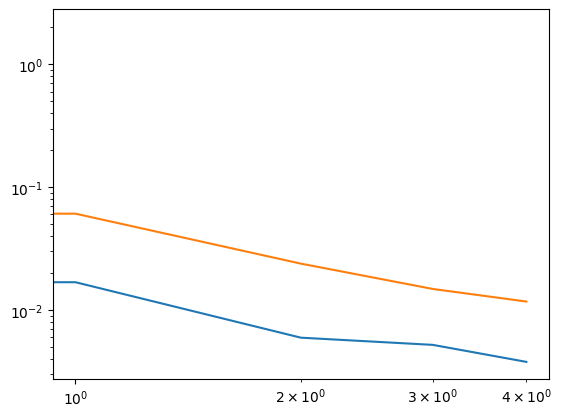

In [50]:
## training on small dataset works
# suppose model.eval() isn't called
def test_without_modelEval(model, dataloader, loss_fun, device):
    #model.eval()
    test_error = 0
    nbatches = len(dataloader)
    with torch.no_grad():
        for (X, y) in dataloader:
            X, y =  X.to(device), y.to(device)
            pred = model(X)
            loss = loss_fun(pred, y)
            test_error += loss.item()
    test_error /= nbatches
    return test_error

history = 5
batch_size = 64
training_dataloader, testing_dataloader, dimensions = make_training_testing_datasets(data, history, batch_size)
model = PFNO(
            (Nx, Nf), 
            Nlifted, 
            (Nk_truncated,), 
            depth
            ).to(device) 
lr = 2E-04
optimizer = torch.optim.Adam(model.parameters(), lr = lr)

train_errors = []
validation_errors = []
epochs = 500
for epoch in range(epochs):
    
    train_loss = train(model, training_dataloader, loss_fun, optimizer, device)
    test_loss = test_without_modelEval(model, testing_dataloader, loss_fun, device)

    if epoch % 100 == 0: 
        train_errors += [train_loss]
        validation_errors += [test_loss]
        print(f' Training error: {train_loss}, Testing error: {test_loss}')
        lr *= 0.8
        optimizer = torch.optim.Adam(model.parameters(), lr = lr)
        
plt.figure()
plt.plot(train_errors, label='training')
plt.plot(validation_errors, label='validation')
plt.loglog()

 ## Remarks about forgetting model.eval()
 testing accuracy decreases by an order of magnitude

 Training error: 1.777146005630493, Testing error: 1.8560959189026445, Contaminated testing error: 1.8482754691954582
 Training error: 0.33277263641357424, Testing error: 0.6086208643736662, Contaminated testing error: 0.5671585529081283
 Training error: 0.054432307928800584, Testing error: 0.20406951230985146, Contaminated testing error: 0.17943814685267787
 Training error: 0.015977852419018744, Testing error: 0.0934183042910364, Contaminated testing error: 0.0816516669527177
 Training error: 0.010392118990421296, Testing error: 0.06603714258030609, Contaminated testing error: 0.05643754716842405


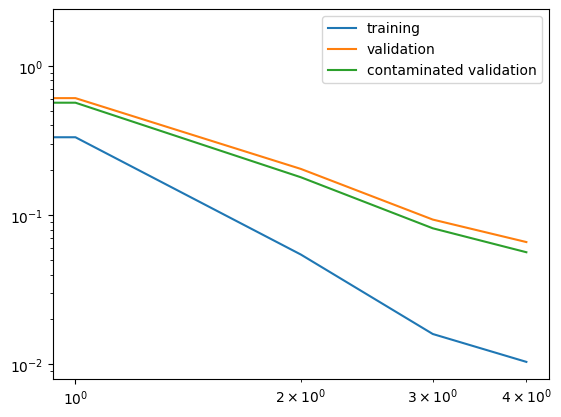

In [18]:
# Let's create some data leakage
history = 5
batch_size = 64
# small batch size: expect bad validation error
training_dataloader1, testing_dataloader1, dimensions = make_training_testing_datasets(data, history, batch_size, training_size=5*batch_size)
_, testing_dataloader2, dimensions = make_training_testing_datasets(data, history, batch_size, training_size=batch_size//2) 
Nx = dimensions[1]
Nf = dimensions[-1]
Nlifted = 16
Nk_truncated = 10
loss_fun = H1Loss(reduction='mean', dim=1)

model = PFNO(
            (Nx, Nf), 
            Nlifted, 
            (Nk_truncated,), 
            history
            ).to(device) 
lr = 2E-04
optimizer = torch.optim.Adam(model.parameters(), lr = lr)

train_errors = []
validation_errors = []
validation_errors2 = []
epochs = 500
for epoch in range(epochs):
    
    train_loss = train(model, training_dataloader1, loss_fun, optimizer, device)
    test_loss1 = test(model, testing_dataloader1, loss_fun, device)
    test_loss2 = test(model, testing_dataloader2, loss_fun, device)

    if epoch % 100 == 0: 
        train_errors += [train_loss]
        validation_errors += [test_loss1]
        validation_errors2 += [test_loss2]
        print(f' Training error: {train_loss}, Testing error: {test_loss1}, Contaminated testing error: {test_loss2}')
        lr *= 0.8
        optimizer = torch.optim.Adam(model.parameters(), lr = lr)
        
plt.figure()
plt.plot(train_errors, label='training')
plt.plot(validation_errors, label='validation')
plt.plot(validation_errors2, label='contaminated validation')
plt.loglog()
plt.legend()

## Remarks on data leakage
contaminated data always yields better validation results, though the gap is small (probably because the unseen data dominates the validation sets)

In [25]:
# loop through model parameters
total = 0
for name, p in model.named_parameters():
    print(f'name: {name}, number of elements: {p.numel()}' )
    total += p.numel()
print(total)

name: initial_layer.weight, number of elements: 16
name: initial_layer.bias, number of elements: 16
name: final_layer.weight, number of elements: 16
name: final_layer.bias, number of elements: 1
name: stack.0.1.0.weights, number of elements: 4352
name: stack.0.1.0.bias, number of elements: 256
name: stack.0.1.1.weight, number of elements: 32
name: stack.0.1.1.bias, number of elements: 32
name: stack.1.1.0.weights, number of elements: 4352
name: stack.1.1.0.bias, number of elements: 256
name: stack.1.1.1.weight, number of elements: 32
name: stack.1.1.1.bias, number of elements: 32
name: stack.2.1.0.weights, number of elements: 4352
name: stack.2.1.0.bias, number of elements: 256
name: stack.2.1.1.weight, number of elements: 32
name: stack.2.1.1.bias, number of elements: 32
name: stack.3.1.0.weights, number of elements: 4352
name: stack.3.1.0.bias, number of elements: 256
name: stack.3.1.1.weight, number of elements: 32
name: stack.3.1.1.bias, number of elements: 32
name: stack.4.1.0.wei

In [26]:
# see if require_grad()
with torch.no_grad(): # this doesn't set them to false
    for p in model.parameters():
        print(p.requires_grad)

False
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True


In [23]:
model.initial_layer.weight.requires_grad = False
with torch.no_grad(): # this doesn't set them to false
    for p in model.parameters():
        print(p.requires_grad)

False
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True


In [35]:
for name, p in model.named_parameters():
    if p.grad is not None:
        print(f'{name}, average value: {p.grad.norm().detach().numpy()}')

initial_layer.bias, average value: 0.03322192281484604
final_layer.weight, average value: 1.0591905117034912
final_layer.bias, average value: 2.270098775625229e-09
stack.0.1.0.weights, average value: 0.05196264013648033
stack.0.1.0.bias, average value: 0.08242471516132355
stack.0.1.1.weight, average value: 0.08951356261968613
stack.0.1.1.bias, average value: 0.06087091565132141
stack.1.1.0.weights, average value: 0.05081646516919136
stack.1.1.0.bias, average value: 0.08306659013032913
stack.1.1.1.weight, average value: 0.10914041101932526
stack.1.1.1.bias, average value: 0.05997611954808235
stack.2.1.0.weights, average value: 0.03915847837924957
stack.2.1.0.bias, average value: 0.06531325727701187
stack.2.1.1.weight, average value: 0.06687159091234207
stack.2.1.1.bias, average value: 0.03458453342318535
stack.3.1.0.weights, average value: 0.03269227221608162
stack.3.1.0.bias, average value: 0.054147906601428986
stack.3.1.1.weight, average value: 0.06545613706111908
stack.3.1.1.bias, av

In [31]:
optimizer.zero_grad(set_to_none=True)
#optimizer = torch.optim.Adam(model.parameters(), lr = lr)
with torch.no_grad():
    for name, p in model.named_parameters():
        if p.grad is not None:
            print(f'{name}, average value: {torch.mean(p.grad).detach().numpy()}')

In [33]:
(X, y) = next(iter(testing_dataloader))
loss_fun(model(X), y).backward() # this computes gradients based on the loss (with back propagation)

for name, p in model.named_parameters():
    if p.grad is not None:
        print(f'{name}, average value: {torch.mean(p.grad).detach().numpy()}')

initial_layer.bias, average value: 0.00782819651067257
final_layer.weight, average value: 0.02561822161078453
final_layer.bias, average value: -2.270098775625229e-09
stack.0.1.0.weights, average value: (-1.5876918268986628e-06-1.3977488606542465e-06j)
stack.0.1.0.bias, average value: -2.6943009288515896e-05
stack.0.1.1.weight, average value: 0.007514801807701588
stack.0.1.1.bias, average value: -1.1641532182693481e-10
stack.1.1.0.weights, average value: (-1.1664404837574693e-06-1.9667916149046505e-06j)
stack.1.1.0.bias, average value: -1.9153783796355128e-05
stack.1.1.1.weight, average value: 0.007905319333076477
stack.1.1.1.bias, average value: 1.7462298274040222e-10
stack.2.1.0.weights, average value: (-1.5323447541959467e-06-6.485374797193799e-07j)
stack.2.1.0.bias, average value: -2.546835457906127e-05
stack.2.1.1.weight, average value: 0.005849793087691069
stack.2.1.1.bias, average value: 5.820766091346741e-11
stack.3.1.0.weights, average value: (-8.313971875395509e-07-4.547751757